# Project 2: A/B Testing for Vanguard

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import datetime
import scipy.stats as st

## Load and clean the datasets

In [6]:
df1 = pd.read_csv(r"\Users\User\Desktop\Ironhack_DA\Project 2- EDA\df_final_demo.txt")
df2 = pd.read_csv(r"\Users\User\Desktop\Ironhack_DA\Project 2- EDA\df_final_experiment_clients.txt") # contains Variation per client ID
pt1 = pd.read_csv(r"\Users\User\Desktop\Ironhack_DA\Project 2- EDA\df_final_web_data_pt_1.txt")
pt2 = pd.read_csv(r"\Users\User\Desktop\Ironhack_DA\Project 2- EDA\df_final_web_data_pt_2.txt")

pt1_pt2 = pd.concat([pt1, pt2], axis=0)

df1_variation = pd.merge(df1, df2, on='client_id', how='inner')
pt1_pt2_variation = pd.merge(pt1_pt2, df1_variation, on='client_id', how='inner')

In [7]:
pt1_pt2_variation.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test


In [8]:
pt1_pt2_variation.sort_values(by='client_id')
pt1_pt2_variation.process_step.unique() # all clients went through the process steps

array(['step_3', 'step_2', 'step_1', 'start', 'confirm'], dtype=object)

In [9]:
pt1_pt2_variation['Variation'].fillna('Unknown', inplace=True) # Replace NaNs with 'Unknown' 

C:\Users\User\AppData\Local\Temp\ipykernel_18544\2466444471.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pt1_pt2_variation['Variation'].fillna('Unknown', inplace=True) # Replace NaNs with 'Unknown'


In [10]:
# Number of clients
pt1_pt2_variation['client_id'].nunique()

70609

In [11]:
# Check dtypes
pt1_pt2_variation.dtypes

client_id             int64
visitor_id           object
visit_id             object
process_step         object
date_time            object
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                object
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
Variation            object
dtype: object

In [12]:
# Check for nulls
pt1_pt2_variation.isna().sum() 

client_id             0
visitor_id            0
visit_id              0
process_step          0
date_time             0
clnt_tenure_yr      115
clnt_tenure_mnth    115
clnt_age            127
gendr               115
num_accts           115
bal                 115
calls_6_mnth        115
logons_6_mnth       115
Variation             0
dtype: int64

In [13]:
# Rename the column from 'gendr' to 'gender'
pt1_pt2_variation = pt1_pt2_variation.rename(columns={"gendr": "gender"})

# Fill missing values in 'gender' with 'U'
pt1_pt2_variation['gender'] = pt1_pt2_variation['gender'].fillna('U')

# Replace gender 'X' by 'U'
pt1_pt2_variation['gender'] = pt1_pt2_variation['gender'].replace('X', 'U')


In [14]:
# Fill missing values in columns with the column's mean
pt1_pt2_variation['clnt_tenure_yr'] = pt1_pt2_variation['clnt_tenure_yr'].fillna(pt1_pt2_variation['clnt_tenure_yr'].mean())
pt1_pt2_variation['clnt_tenure_mnth'] = pt1_pt2_variation['clnt_tenure_mnth'].fillna(pt1_pt2_variation['clnt_tenure_mnth'].mean())
pt1_pt2_variation['clnt_age'] = pt1_pt2_variation['clnt_age'].fillna(pt1_pt2_variation['clnt_age'].mean())
pt1_pt2_variation['num_accts'] = pt1_pt2_variation['num_accts'].fillna(pt1_pt2_variation['num_accts'].mean())
pt1_pt2_variation['bal'] = pt1_pt2_variation['bal'].fillna(pt1_pt2_variation['bal'].mean())
pt1_pt2_variation['calls_6_mnth'] = pt1_pt2_variation['calls_6_mnth'].fillna(pt1_pt2_variation['calls_6_mnth'].mean())
pt1_pt2_variation['logons_6_mnth'] = pt1_pt2_variation['logons_6_mnth'].fillna(pt1_pt2_variation['logons_6_mnth'].mean())

In [15]:
#remove duplicated rows
pt1_pt2_variation = pt1_pt2_variation.drop_duplicates()

pt1_pt2_variation

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449826,9895983,473024645_56027518531,498981662_93503779869_272484,step_3,2017-06-15 19:52:09,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0,Unknown
449827,9895983,473024645_56027518531,498981662_93503779869_272484,step_2,2017-06-15 19:50:37,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0,Unknown
449828,9895983,473024645_56027518531,498981662_93503779869_272484,step_1,2017-06-15 19:50:05,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0,Unknown
449829,9895983,473024645_56027518531,498981662_93503779869_272484,start,2017-06-15 19:50:00,10.0,121.0,49.0,M,2.0,97748.22,2.0,2.0,Unknown


In [16]:
# Summary statistics of primary client attributes

primary_client_summary = pt1_pt2_variation.groupby("client_id").agg({
    "clnt_age": "mean",
    "clnt_tenure_yr": "mean",
    "num_accts": "mean",
    "bal": "mean",
    "calls_6_mnth": "mean",
    "logons_6_mnth": "mean"
}).reset_index()

# Print the summary
primary_client_summary.describe()

,client_id,clnt_age,clnt_tenure_yr,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060900e+04,70609.000000,70609.000000,70609.000000,7.060900e+04,70609.000000,70609.000000
mean,5.004992e+06,46.442498,12.052986,2.255530,1.474477e+05,3.382507,5.566768
std,2.877278e+06,15.589626,6.871138,0.534944,3.014789e+05,2.236359,2.353053
min,1.690000e+02,13.500000,2.000000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,32.500000,6.000000,2.000000,3.735012e+04,1.000000,4.000000
50%,5.016978e+06,47.000000,11.000000,2.000000,6.334555e+04,3.000000,5.000000
75%,7.483085e+06,59.000000,16.000000,2.000000,1.376355e+05,6.000000,7.000000
max,9.999839e+06,96.000000,62.000000,8.000000,1.632004e+07,7.000000,9.000000


In [17]:
#clients by Variation

all_users = pt1_pt2_variation.groupby(["Variation"]).agg({
    "client_id":'nunique'
})
all_users = pd.DataFrame(all_users)
all_users = all_users.reset_index()
all_users

,Variation,client_id
0,Control,23532
1,Test,26968
2,Unknown,20109


<span style="color: orange;"># CSV first export: </span>

In [19]:
pt1_pt2_variation.to_csv('pt1_pt2_variation_1.csv', index=False)

## Client findings

### 1. Client Demographics
The average client age is ~46.44 years, but there’s a wide range (min: 13.5, max: 96), meaning users vary significantly.
Most users are middle-aged to older investors (50th percentile: 47 years, 75th percentile: 59 years).
A small percentage of clients are younger investors, possibly new to Vanguard.

### 2. Client Tenure (Years as Vanguard Customers)
The average tenure is ~12 years, indicating long-term relationships with Vanguard.
Some clients have been customers for decades (max: 62 years), reinforcing loyalty.

### 3. Account and Balance Trends
Number of Accounts:
Most clients hold ~2 accounts (median and 75th percentile).
Some have up to 8 accounts, possibly managing diverse investments.
Balances:
The median account balance is ~$63,000, but it varies widely (min: ~$13,789, max: ~$16.32M).
A subset of clients has very high-value accounts, indicating affluent investors.

### 4. Client Engagement (Calls & Logins in the Last 6 Months)
Customer Service Calls:
Average 3.38 calls in six months—suggesting moderate client interaction.
Some clients never call, while others engage frequently (up to 7 calls).
Logins:
Most clients log in regularly (~5-6 times in six months).
Some log in almost daily, indicating highly engaged users.

### Key Takeaways
Diverse customer base ranging from new investors to long-term, high-net-worth clients.
Strong digital engagement, with frequent logins and occasional service calls.
The presence of high-value investors suggests the need for personalized services and strong UI enhancements.

## Explore demographics further
### Correlation between client tenure, logons, numaccts and balance

In [22]:
# Select relevant numerical columns
correlation_columns = ["clnt_tenure_yr", "logons_6_mnth", "num_accts", "bal"]

# Compute the correlation matrix

correlation_matrix =pt1_pt2_variation[correlation_columns].corr()

# Display the correlation matrix
print(correlation_matrix)
correlation_matrix

                clnt_tenure_yr  logons_6_mnth  num_accts       bal
clnt_tenure_yr        1.000000       0.056223   0.159639  0.199197
logons_6_mnth         0.056223       1.000000   0.224233  0.165527
num_accts             0.159639       0.224233   1.000000  0.271644
bal                   0.199197       0.165527   0.271644  1.000000


,clnt_tenure_yr,logons_6_mnth,num_accts,bal
clnt_tenure_yr,1.000000,0.056223,0.159639,0.199197
logons_6_mnth,0.056223,1.000000,0.224233,0.165527
num_accts,0.159639,0.224233,1.000000,0.271644
bal,0.199197,0.165527,0.271644,1.000000


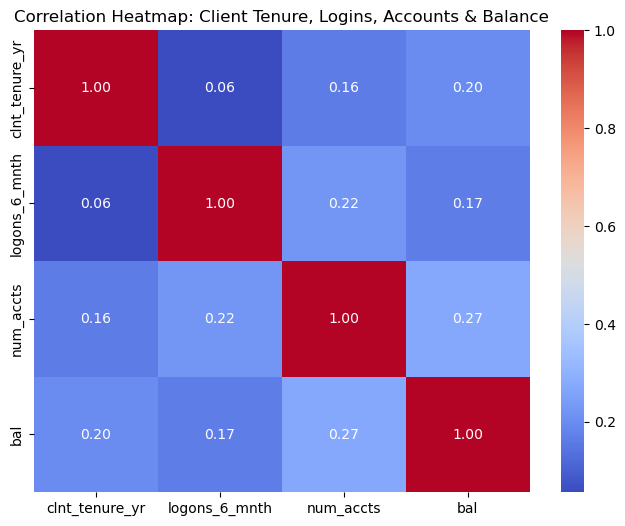

In [23]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap: Client Tenure, Logins, Accounts & Balance")
plt.show()

#### Key Takeaways
Tenure has minimal impact on digital engagement (logins).
Clients with more accounts log in more frequently, likely to manage investments.
Balance increases with tenure and number of accounts, showing long-term clients accumulate wealth over time.

### Gender and balance

In [26]:
pd.set_option('display.float_format', '{:,.0f}'.format)
pt1_pt2_variation.groupby("gender").agg(
    bal_sum=pd.NamedAgg(column="bal", aggfunc="sum"),
    bal_mean=pd.NamedAgg(column="bal", aggfunc="mean")
)

,bal_sum,bal_mean
gender,,
F,"20,604,957,082","143,054"
M,"34,795,510,005","232,176"
U,"15,077,578,411","100,521"


### Gender per group 

In [28]:
# Delete duplicates of client_id
unique_clients_df = pt1_pt2_variation.drop_duplicates(subset=['client_id'])

# Merge on client_id
clients_experiment_df = pd.merge(unique_clients_df, unique_clients_df, on='client_id')

# Get gender numbers per group
grouped_clients_gender_df = unique_clients_df.groupby(['Variation', 'gender']).size().reset_index(name='Count')

grouped_clients_gender_df


,Variation,gender,Count
0,Control,F,7543
1,Control,M,7970
2,Control,U,8019
3,Test,F,8716
4,Test,M,8977
5,Test,U,9275
6,Unknown,F,6487
7,Unknown,M,6777
8,Unknown,U,6845


<Axes: xlabel='Variation', ylabel='Count'>

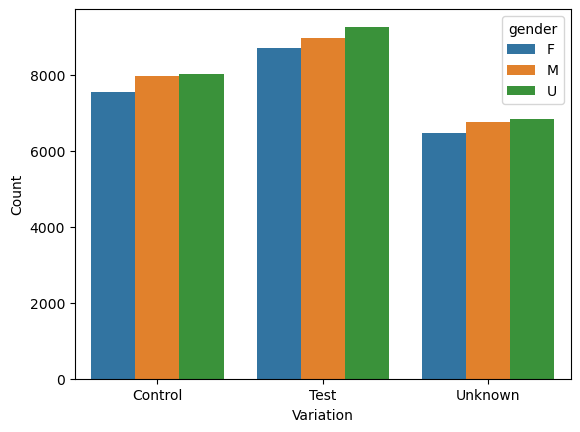

In [29]:
# Create a bar chart with clients on both groups by gender
sns.barplot(data=grouped_clients_gender_df, x='Variation', y='Count', hue='gender')

### Gender ratio per group 

<h4 style="color: red; font-weight: bold;">

In [31]:
# Make sure 'Count' is float
grouped_clients_gender_df['Count'] = grouped_clients_gender_df['Count'].astype(float)

# Calculate the total count per Variation
grouped_clients_gender_df['Total'] = grouped_clients_gender_df.groupby('Variation')['Count'].transform('sum')

# Calculate the percentage for each gender in each group
grouped_clients_gender_df['Percentage'] = (grouped_clients_gender_df['Count'] / grouped_clients_gender_df['Total']) * 100

# Round the percentages to 2 decimal places
grouped_clients_gender_df['Percentage'] = grouped_clients_gender_df['Percentage'].round(2)

# Pivot the data
gender_percentages = grouped_clients_gender_df.pivot(index='Variation', columns='gender', values='Percentage').reset_index()

# Remove the 'gender' columns name
gender_percentages.columns.name = None

# Format the percentages to always show 2 decimals
for col in gender_percentages.columns:
    if col != 'Variation':  # Only apply to percentage columns
        gender_percentages[col] = gender_percentages[col].apply(lambda x: f"{x:.2f}")

gender_percentages

,Variation,F,M,U
0,Control,32.05,33.87,34.08
1,Test,32.32,33.29,34.39
2,Unknown,32.26,33.70,34.04


### Age distribution 

<h4 style="color: red; font-weight: bold;">

<Axes: xlabel='clnt_age', ylabel='Count'>

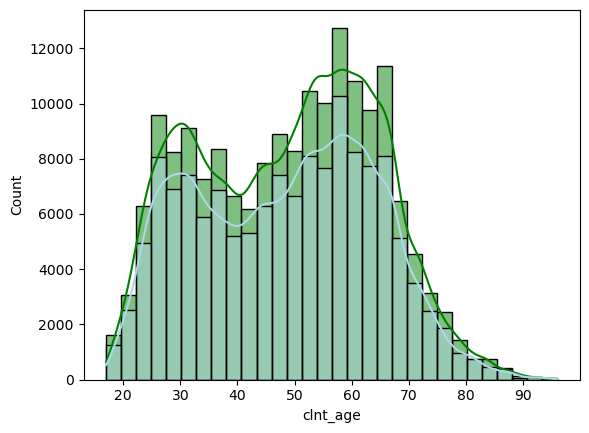

In [33]:
# Create a histoplot for age of clients overall 
sns.histplot(pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Test']['clnt_age'], kde=True, bins=30, color="green")
sns.histplot(pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Control']['clnt_age'], kde=True, bins=30, color="lightblue")

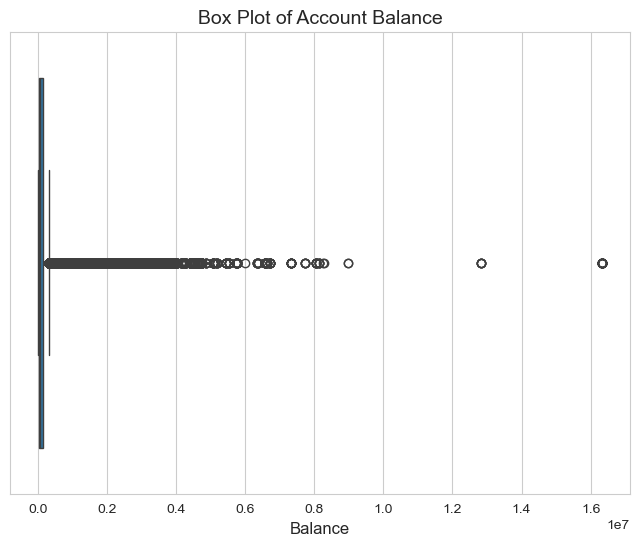

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Create box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=pt1_pt2_variation["bal"])

# Add title and labels
plt.title("Box Plot of Account Balance", fontsize=14)
plt.xlabel("Balance", fontsize=12)

# Show plot
plt.show()

In [35]:
# Step 1: Create membership level category
def assign_membership_level(bal):
    if bal < 1_000_000:
        return 'Entry Level'
    elif bal < 3_000_000:
        return 'Bronze'
    elif bal < 5_000_000:
        return 'Silver'
    elif bal < 7_000_000:
        return 'Gold'
    else:
        return 'Platinum'

# Apply the function to create a new column for membership levels
pt1_pt2_variation['membership_level'] = pt1_pt2_variation['bal'].apply(assign_membership_level)


# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Drop conflicting 'total_visits' column in pt1_pt2_variation (if exists)
if 'total_visits' in pt1_pt2_variation.columns:
    pt1_pt2_variation = pt1_pt2_variation.drop(columns=['total_visits'])

# Merge visit count back into the original DataFrame
pt1_pt2_variation = pt1_pt2_variation.merge(visit_count, on='client_id', how='left')

# Step 5: Group by 'membership_level' and 'Variation' to sum and count unique clients
grouped_df = pt1_pt2_variation.groupby(['membership_level']).agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per membership level
    total_clients=('client_id', 'nunique'),  # Count unique clients per membership level
    total_client_bal=('bal', 'sum')  # sum client balance
).reset_index()


# Define the custom order for membership levels
membership_order = ['Entry Level', 'Bronze', 'Silver', 'Gold', 'Platinum']
grouped_df['membership_level'] = pd.Categorical(grouped_df['membership_level'], categories=membership_order, ordered=True)

# Sort the DataFrame by Variation and then by the custom order of membership levels
grouped_df = grouped_df.sort_values(by=['membership_level']).reset_index(drop=True)

grouped_df

,membership_level,total_visits,total_clients,total_client_bal
0,Entry Level,3851818,69431,"54,646,284,423"
1,Bronze,80596,1058,"11,942,418,222"
2,Silver,6376,98,"2,574,622,886"
3,Gold,641,13,"501,921,724"
4,Platinum,1166,9,"812,798,242"


## KPIs

### KPI 1: Completion rate
#### What is completion? --> A client who reaches 'confirm' in the process. 

In [38]:
# Look at number of unique clients per step

kpi1_all_steps = pt1_pt2_variation.groupby(["Variation", "process_step"]).agg({
    "client_id": 'nunique'
})
kpi1_all_steps

client_id
Variation process_step           
Control   confirm           15434
          start             23397
          step_1            20152
          step_2            18650
          step_3            17422
Test      confirm           18687
          start             26679
          step_1            24267
          step_2            22258
          step_3            20881
Unknown   confirm           13679
          start             19938
          step_1            17734
          step_2            16310
          step_3            15310

In [39]:
all_users

,Variation,client_id
0,Control,23532
1,Test,26968
2,Unknown,20109


In [40]:
confirm_steps = pd.DataFrame(kpi1_all_steps.xs('confirm', level='process_step')).reset_index()
confirm_steps['completion_rate'] = ((confirm_steps['client_id'] / all_users['client_id'].astype(float))*100)
confirm_steps

,Variation,client_id,completion_rate
0,Control,15434,66
1,Test,18687,69
2,Unknown,13679,68


### Looking at users who don't hit 'start'

In [42]:
all_users_ids = pt1_pt2_variation[['Variation', 'client_id']].drop_duplicates()
all_users_ids
started_ids = pt1_pt2_variation[pt1_pt2_variation['process_step'] == 'start'][['Variation', 'client_id']].drop_duplicates()
# Find users in all_users_ids who are NOT in started_ids
not_started = all_users_ids.merge(started_ids, on=['Variation', 'client_id'], how='left', indicator=True)
never_started = not_started[not_started['_merge'] == 'left_only']
never_started_count = never_started.groupby('Variation')['client_id'].nunique()
print(never_started_count)

Variation
Control    135
Test       289
Unknown    171
Name: client_id, dtype: int64


In [43]:
# Look at an example client who didn't start

pt1_pt2_variation[pt1_pt2_variation['client_id'] == 5645966]

# We see that people who don't start can still add to the 'confirm' step.

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,membership_level,total_visits
1485,5645966,852362861_88803754649,254092443_59505279697_931599,confirm,2017-04-14 16:12:30,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1486,5645966,852362861_88803754649,254092443_59505279697_931599,step_3,2017-04-14 16:11:33,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1487,5645966,852362861_88803754649,254092443_59505279697_931599,step_2,2017-04-14 16:11:21,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1488,5645966,852362861_88803754649,254092443_59505279697_931599,step_3,2017-04-14 16:11:13,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1489,5645966,852362861_88803754649,254092443_59505279697_931599,step_2,2017-04-14 16:11:00,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1490,5645966,852362861_88803754649,254092443_59505279697_931599,step_3,2017-04-14 16:10:48,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7
1491,5645966,852362861_88803754649,254092443_59505279697_931599,step_2,2017-04-14 16:06:35,4,50,26,U,2,"59,061",3,6,Control,Entry Level,7


### Exploring a different definition of 'completion': someone who hits all the steps in the right order without repeats or errors

In [45]:
# Getting only those clients who go through the funnel without repeats, errors

# Define the expected full funnel path
expected_sequence = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# Step 1: Get the list of process steps per client, in order
client_sequences = (
    pt1_pt2_variation
    .sort_values(['client_id', 'date_time'])  # sort chronologically
    .groupby('client_id')['process_step']
    .apply(list)
)

# Step 2: Filter clients whose sequence matches exactly
valid_clients = client_sequences[client_sequences.apply(lambda x: x == expected_sequence)].index

# Step 3: Keep only those rows in the original dataframe
clean_funnel_df = pt1_pt2_variation[
    pt1_pt2_variation['client_id'].isin(valid_clients)
]

# clean_funnel_df # All of the clients who completed the funnel correctly as per the definition

In [46]:
# Number of valid clients per group 

start_to_confirm = pd.DataFrame(clean_funnel_df.groupby('Variation')['client_id'].nunique().reset_index())

In [47]:
start_to_confirm

,Variation,client_id
0,Control,7359
1,Test,8272
2,Unknown,6330


In [48]:
all_users

,Variation,client_id
0,Control,23532
1,Test,26968
2,Unknown,20109


In [49]:
# Completion rate for the second definition

start_to_confirm['completion_rate'] = (
    start_to_confirm['client_id'] / all_users['client_id']*100
)
start_to_confirm

,Variation,client_id,completion_rate
0,Control,7359,31
1,Test,8272,31
2,Unknown,6330,31


#### ! We see that the completion rate for the full funnel is the same for each group. 

### Completion rate for our hypothesis testing: those who reach 'confirm' 

In [52]:
confirm_steps = confirm_steps.merge(all_users, on='Variation', how='inner')

In [53]:
confirm_steps

,Variation,client_id_x,completion_rate,client_id_y
0,Control,15434,66,23532
1,Test,18687,69,26968
2,Unknown,13679,68,20109


### Hypothesis testing KPI1

H0: P-test - p-control > 0.05

H1: P-test - P-control <  0.05

In [56]:
test_data = confirm_steps.loc[confirm_steps['Variation'] == 'Test']
control_data = confirm_steps.loc[confirm_steps['Variation'] == 'Control']

# Extract sample sizes (n) and observed completion rates (p) for Control and Test groups.
n_control = control_data['client_id_x'].values[0]
n_test = test_data['client_id_x'].values[0]

p_control = control_data['completion_rate'].values[0] / 100   # Convert completion rate % -> decimal
p_test = test_data['completion_rate'].values[0] / 100         # Convert completion rate % -> decimal

# minimum lift:
delta = 0.05

# variance for each group:
var_control = (p_control * (1 - p_control)) / n_control
var_test = (p_test * (1 - p_test)) / n_test

# Standard Error (SE) is the square root of the sum of these two variances:
se = (var_control + var_test) ** 0.5

# Calculate the Z-score
z = ((p_test - p_control) - delta) / se

# Calculate the p-value (one-tailed test):
# Since you care only if Test is greater than Control by more than 5%
p_value = 1 - st.norm.cdf(z)

# 6. Print results:
print(f"Z-score: {z}")
print(f"P-value: {p_value}")

# 7. Conclusion:
#Fail to Reject the Null Hypothesis: 
#There is not enough evidence to conclude that the Test group's completion rate is greater than the Control group's completion rate by more than 5%. 
#The Test process does not show a statistically significant improvement over the Control proces

Z-score: -2.5373428523931896
P-value: 0.9944151248285257


### KPI 2: Time Spent on Each Step
#### What is the average duration users spend on each step?

In [58]:
# # Calculate the average time per step

# # Step 1: Keep only the first time each client hits each step
first_steps = pt1_pt2_variation.sort_values("date_time").drop_duplicates(subset=["client_id", "process_step"], keep="first")


# # Step 2: Pivot so each process_step is a column with the timestamp of first entry
step_times = first_steps.pivot(index="client_id", columns="process_step", values="date_time")

# # Step 3: Convert to datetime if needed
step_times = step_times.apply(pd.to_datetime)

# # Step 4: Calculate time differences between steps
# # Example: time from start to step_1
step_times["start_to_step_1"] = (step_times["step_1"] - step_times["start"]).dt.total_seconds() / 60
step_times["step_1_to_step_2"] = (step_times["step_2"] - step_times["step_1"]).dt.total_seconds() / 60
step_times["step_2_to_step_3"] = (step_times["step_3"] - step_times["step_2"]).dt.total_seconds() / 60
step_times["step_3_to_confirm"] = (step_times["confirm"] - step_times["step_3"]).dt.total_seconds() / 60

# # Step 5: Get the averages
avg_times = step_times[["start_to_step_1", "step_1_to_step_2", "step_2_to_step_3", "step_3_to_confirm"]].mean()

avg_times

process_step
start_to_step_1     1,776
step_1_to_step_2      794
step_2_to_step_3      809
step_3_to_confirm   1,352
dtype: float64

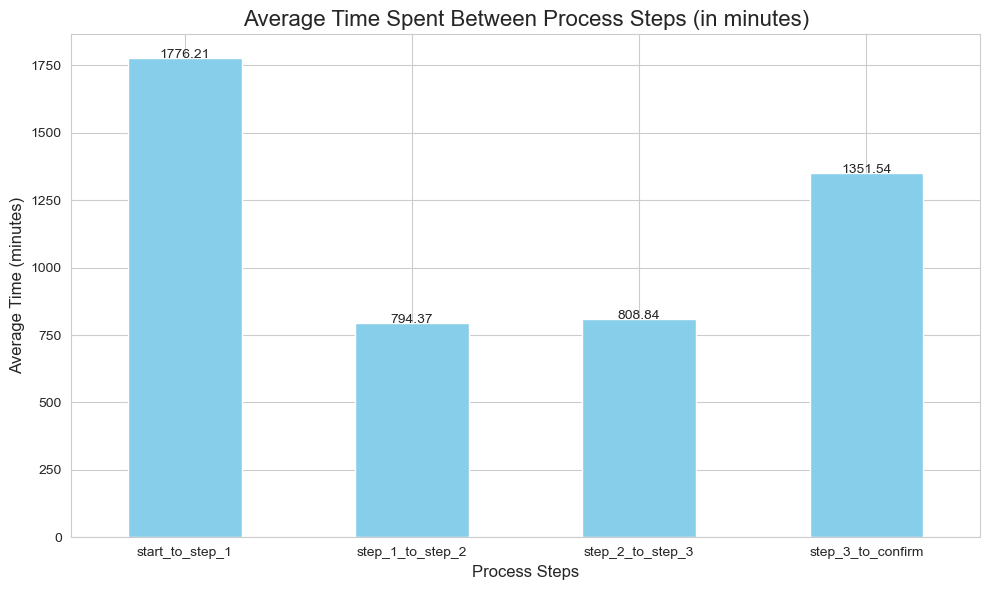

In [59]:
# Step 6: Create a bar plot for avg_times
plt.figure(figsize=(10, 6))
avg_times.plot(kind='bar', color='skyblue')

# Set plot labels and title
plt.title('Average Time Spent Between Process Steps (in minutes)', fontsize=16)
plt.xlabel('Process Steps', fontsize=12)
plt.ylabel('Average Time (minutes)', fontsize=12)

# Show values on top of the bars
for index, value in enumerate(avg_times):
    plt.text(index, value + 0.1, f'{value:.2f}', ha='center')

# Show the plot
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
# Calculate the average time per step on Test group 

# Drop 'Unknown' and 'Control' from Variation
pt1_pt2_clean = pt1_pt2_variation[~pt1_pt2_variation["Variation"].isin(["Unknown", "Control"])]

# Step 1: Keep only the first time each client hits each step
first_steps = pt1_pt2_clean.sort_values("date_time").drop_duplicates(
    subset=["visit_id", "process_step"], keep="first"
)

# Step 2: Pivot so each process_step is a column with the timestamp of first entry
step_times = first_steps.pivot(index="visit_id", columns="process_step", values="date_time")

# Step 3: Convert to datetime if needed
step_times = step_times.apply(pd.to_datetime)

# Step 4: Calculate time differences between steps
# Example: time from start to step_1
step_times["start_to_step_1"] = (step_times["step_1"] - step_times["start"]).dt.total_seconds() 
step_times["step_1_to_step_2"] = (step_times["step_2"] - step_times["step_1"]).dt.total_seconds() 
step_times["step_2_to_step_3"] = (step_times["step_3"] - step_times["step_2"]).dt.total_seconds() 
step_times["step_3_to_confirm"] = (step_times["confirm"] - step_times["step_3"]).dt.total_seconds() 

# Step 5: Get the averages
avg_times_test = step_times[["start_to_step_1", "step_1_to_step_2", "step_2_to_step_3", "step_3_to_confirm"]].mean()
avg_times_test = pd.DataFrame(avg_times_test.round(2)).reset_index(drop=False)  # Round to 2 decimal places
avg_times_test = avg_times_test.rename(columns={0: 'AVG time for Test'})
avg_times_test = pd.DataFrame(avg_times_test).reset_index(drop=True)
avg_times_test



,process_step,AVG time for Test
0,start_to_step_1,51
1,step_1_to_step_2,76
2,step_2_to_step_3,107
3,step_3_to_confirm,143


<Figure size 1000x600 with 0 Axes>

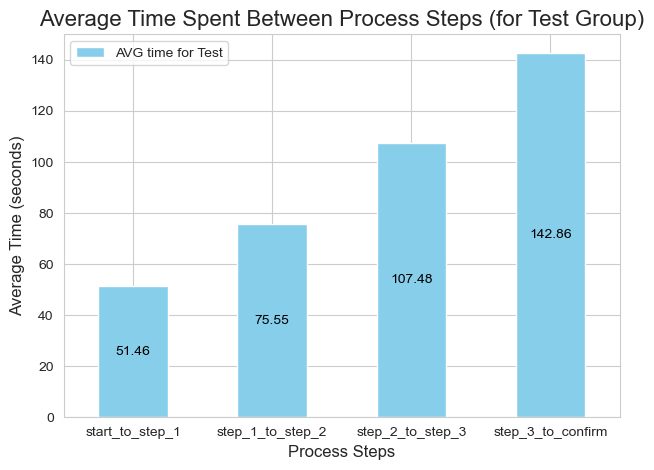

In [61]:
# Step 7: Create a bar plot for the average times

# Assuming 'avg_times_Test' has two columns: 'process_step' and 'AVG time for Test'
plt.figure(figsize=(10, 6))

# Plot the bar chart with 'process_step' as x and 'AVG time for Test' as y
ax = avg_times_test.plot(kind='bar', x='process_step', y='AVG time for Test', color='skyblue')

# Set plot labels and title
plt.title('Average Time Spent Between Process Steps (for Test Group)', fontsize=16)
plt.xlabel('Process Steps', fontsize=12)
plt.ylabel('Average Time (seconds)', fontsize=12)

# Show the values inside the bars
for index, value in enumerate(avg_times_test['AVG time for Test']):
    # Add text inside the bars
    ax.text(index, value / 2, f'{value:.2f}', ha='center', va='center', fontsize=10, color='black')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=0)

# Use tight_layout to ensure the plot fits into the figure area without clipping
plt.tight_layout()

# Show the plot
plt.show()

In [62]:
# Calculate the average time per step on Control group 

# Drop 'Unknown' and 'Test' from Variation
pt1_pt2_clean = pt1_pt2_variation[~pt1_pt2_variation["Variation"].isin(["Unknown", "Test"])]

# Step 1: Keep only the first time each client hits each step
first_steps = pt1_pt2_clean.sort_values("date_time").drop_duplicates(
    subset=["visit_id", "process_step"], keep="first"
)

# Step 2: Pivot so each process_step is a column with the timestamp of first entry
step_times = first_steps.pivot(index="visit_id", columns="process_step", values="date_time")

# Step 3: Convert to datetime if needed
step_times = step_times.apply(pd.to_datetime)

# Step 4: Calculate time differences between steps
# Example: time from start to step_1
step_times["start_to_step_1"] = (step_times["step_1"] - step_times["start"]).dt.total_seconds() 
step_times["step_1_to_step_2"] = (step_times["step_2"] - step_times["step_1"]).dt.total_seconds() 
step_times["step_2_to_step_3"] = (step_times["step_3"] - step_times["step_2"]).dt.total_seconds() 
step_times["step_3_to_confirm"] = (step_times["confirm"] - step_times["step_3"]).dt.total_seconds() 

# Step 5: Get the averages
avg_times_control = step_times[["start_to_step_1", "step_1_to_step_2", "step_2_to_step_3", "step_3_to_confirm"]].mean()
avg_times_control = pd.DataFrame(avg_times_control).reset_index(drop=False)
avg_times_control = avg_times_control.rename(columns={0: 'AVG time for Control'})
avg_times_control = pd.DataFrame(avg_times_control).reset_index(drop=True)
avg_times_control

,process_step,AVG time for Control
0,start_to_step_1,64
1,step_1_to_step_2,50
2,step_2_to_step_3,110
3,step_3_to_confirm,169


<Figure size 1000x600 with 0 Axes>

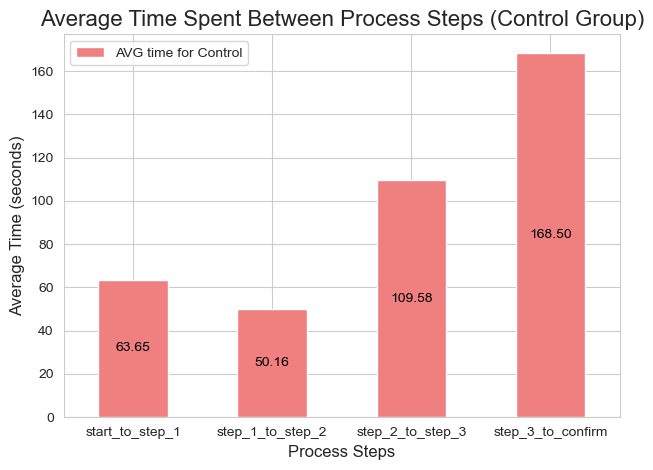

In [63]:
# Step 6: Create a bar plot for the average times for the Control group
# Assuming 'avg_times_control' has two columns: 'process_step' and 'AVG time for Control'
plt.figure(figsize=(10, 6))

# Plot the bar chart with 'process_step' as x and 'AVG time for Control' as y
ax = avg_times_control.plot(kind='bar', x='process_step', y='AVG time for Control', color='lightcoral')

# Set plot labels and title
plt.title('Average Time Spent Between Process Steps (Control Group)', fontsize=16)
plt.xlabel('Process Steps', fontsize=12)
plt.ylabel('Average Time (seconds)', fontsize=12)

# Show the values inside the bars
for index, value in enumerate(avg_times_control['AVG time for Control']):
    # Add text inside the bars, adjusting the position so it's inside
    ax.text(index, value / 2, f'{value:.2f}', ha='center', va='center', fontsize=10, color='black')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=0)

# Use tight_layout to ensure the plot fits into the figure area without clipping
plt.tight_layout()

# Show the plot
plt.show()

In [64]:
merged_avg_times = pd.merge(avg_times_control, avg_times_test, on='process_step', how='inner')
merged_avg_times

,process_step,AVG time for Control,AVG time for Test
0,start_to_step_1,64,51
1,step_1_to_step_2,50,76
2,step_2_to_step_3,110,107
3,step_3_to_confirm,169,143


In [65]:
merged_avg_times.to_csv('merged_avg_times.csv')

In [134]:
#H0 (Null Hypothesis): AVG time for Test >= AVG time for Control
#H1 (Alternative Hypothesis) : AVG time for Test < AVG time for Control

# Perform the t-test
t_statistic, p_value = st.ttest_ind(merged_avg_times['AVG time for Control'], merged_avg_times['AVG time for Test'])

# Print statistics and p-values
print(f"T-Statistic: {t_statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

# Null hypothesis test
if p_value < 0.05 and t_statistic < 0:
    print("Reject the null hypothesis (H0)")
else:
    print("Fail to reject the null hypothesis (H1)")

T-Statistic: 0.1092
P-Value: 0.9166
Fail to reject the null hypothesis (H1)


In [66]:
# Step 1: Convert 'date_time' to datetime format
pt1_pt2_variation['date_time'] = pd.to_datetime(pt1_pt2_variation['date_time'])

# Step 2: Ensure correct sorting by visit_id and date_time
pt1_pt2_variation.sort_values(by=['visit_id', 'date_time'], inplace=True)

# Step 3: Calculate time differences using groupby to handle entries by visit_id
# Using shift to find the time in seconds between steps
pt1_pt2_variation['time_spent'] = pt1_pt2_variation.groupby('visit_id')['date_time'].diff().dt.total_seconds()

# Step 4: Fill NaN values where there are no previous entries (e.g., for 'start')
pt1_pt2_variation.fillna(0, inplace=True)

# Step 5: Display the DataFrame with the time spent column
pt1_pt2_variation

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,membership_level,total_visits,time_spent
106314,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,4,56,60,U,2,"63,130",6,9,Test,Entry Level,7,0
106313,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,4,56,60,U,2,"63,130",6,9,Test,Entry Level,7,52
235345,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,7,88,24,M,2,"26,437",6,9,Test,Entry Level,19,0
235344,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,7,88,24,M,2,"26,437",6,9,Test,Entry Level,19,16
235343,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,7,88,24,M,2,"26,437",6,9,Test,Entry Level,19,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95172,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:49:22,18,227,58,F,2,"1,056,776",6,9,Test,Bronze,11,11
95171,6627522,730634087_44272418812,999988789_76411676596_272843,step_2,2017-04-21 23:50:16,18,227,58,F,2,"1,056,776",6,9,Test,Bronze,11,54
95170,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:51:00,18,227,58,F,2,"1,056,776",6,9,Test,Bronze,11,44
95169,6627522,730634087_44272418812,999988789_76411676596_272843,start,2017-04-21 23:51:09,18,227,58,F,2,"1,056,776",6,9,Test,Bronze,11,9


In [67]:
# Step 1: Create generation category
def assign_generation(age):
    if age < 11:
        return 'Generation Alpha'
    elif age < 27:
        return 'Generation Z'
    elif age < 43:
        return 'Millennials'
    elif age < 58:
        return 'Generation X'
    elif age < 76:
        return 'Baby Boomers'
    else:
        return 'Silent Generation'

# Apply the function to create a new column for generations
pt1_pt2_variation['generation'] = pt1_pt2_variation['clnt_age'].apply(assign_generation)

# Step 2: Filter the DataFrame for Variation 'Test'
test_group = pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Test']

# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Add visit count to test_group DataFrame without column duplication
test_group = test_group.merge(visit_count, on='client_id', how='left', suffixes=('', '_dup'))

# Remove the duplicate column if it exists
if 'total_visits_dup' in test_group.columns:
    test_group.drop(columns=['total_visits_dup'], inplace=True)

# Step 5: Group by 'generation' to sum and count unique clients
grouped_df_test = test_group.groupby('generation').agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per generation
    total_clients=('client_id', 'nunique'),  # Count unique clients per generation
    total_time_spent_seconds=('time_spent', 'sum'),
    average_client_age=('clnt_age', 'mean')
).reset_index()

# Step 6: Calculate average time spent per generation 
grouped_df_test['average_time_spent_seconds'] = grouped_df_test['total_time_spent_seconds'] / grouped_df_test['total_visits'].replace(0, np.nan)

# Step 7: Convert total_time_spent_seconds to float type if needed
grouped_df_test['total_time_spent_seconds'] = grouped_df_test['total_time_spent_seconds'].astype(float)

# Display the new DataFrame for the Test group
grouped_df_test


,generation,total_visits,total_clients,total_time_spent_seconds,average_client_age,average_time_spent_seconds
0,Baby Boomers,584271,7172,"3,999,577",65,7
1,Generation X,471808,8043,"3,708,154",51,8
2,Generation Z,130981,2840,"985,744",23,8
3,Millennials,359423,8292,"2,659,478",34,7
4,Silent Generation,66052,621,"441,806",81,7


In [68]:
# Step 1: Define and assign generation based on age

def assign_generation(age):
    if age < 11:
        return 'Generation Alpha'
    elif age < 27:
        return 'Generation Z'
    elif age < 43:
        return 'Millennials'
    elif age < 58:
        return 'Generation X'
    elif age < 76:
        return 'Baby Boomers'
    else:
        return 'Silent Generation'

# Apply the function to create a new column for generations
pt1_pt2_variation['generation'] = pt1_pt2_variation['clnt_age'].apply(assign_generation)

# Step 2: Filter the DataFrame for Variation 'Control'
control_group = pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Control']

# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Add visit count to test_group DataFrame without column duplication
control_group = control_group.merge(visit_count, on='client_id', how='left', suffixes=('', '_dup'))

# Remove the duplicate column if it exists
if 'total_visits_dup' in test_group.columns:
    control_group.drop(columns=['total_visits_dup'], inplace=True)

# Step 5: Group by 'generation' to sum and count unique clients
grouped_df_control = control_group.groupby('generation').agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per generation
    total_clients=('client_id', 'nunique'),  # Count unique clients per generation
    total_time_spent_seconds=('time_spent', 'sum'),
    average_client_age=('clnt_age', 'mean')
).reset_index()

# Step 6: Calculate average time spent per generation
grouped_df_control['average_time_spent_seconds'] = grouped_df_control['total_time_spent_seconds'] / grouped_df_control['total_visits'].replace(0, np.nan)

# Step 7: Convert total_time_spent_seconds to float type if needed
grouped_df_control['total_time_spent_seconds'] = grouped_df_control['total_time_spent_seconds'].astype(float)

# Display the new DataFrame for the Test group
grouped_df_control


,generation,total_visits,total_clients,total_time_spent_seconds,average_client_age,average_time_spent_seconds
0,Baby Boomers,382323,6489,"3,056,200",65,8
1,Generation X,363237,7028,"2,933,772",51,8
2,Generation Z,108822,2436,"685,550",24,6
3,Millennials,304488,7029,"2,152,766",34,7
4,Silent Generation,39878,550,"293,335",81,7


In [69]:
# Step 1: Define and assign generation based on age

def assign_generation(age):
    if age < 11:
        return 'Generation Alpha'
    elif age < 27:
        return 'Generation Z'
    elif age < 43:
        return 'Millennials'
    elif age < 58:
        return 'Generation X'
    elif age < 76:
        return 'Baby Boomers'
    else:
        return 'Silent Generation'

# Apply the function to create a new column for generations
pt1_pt2_variation['generation'] = pt1_pt2_variation['clnt_age'].apply(assign_generation)

# Step 2: Filter the DataFrame for Variation 'Control'
control_group = pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Control']

# Step 2: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 3: Merge visit count back into the original DataFrame
pt1_pt2_variation = pt1_pt2_variation.merge(visit_count, on='client_id', how='left', suffixes=('', '_dup'))

# Remove the duplicate column if it exists
if 'total_visits_dup' in test_group.columns:
    control_group.drop(columns=['total_visits_dup'], inplace=True)

# Step 4: Group by 'generation' and 'Variation' to get the desired statistics
grouped_df = pt1_pt2_variation.groupby(['generation', 'Variation']).agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per generation
    total_clients=('client_id', 'nunique'),  # Count unique clients per generation
    total_time_spent_seconds=('time_spent', 'sum'),
    average_client_age=('clnt_age', 'mean')
).reset_index()

# Step 5: Calculate average time spent per generation
grouped_df['average_time_spent_seconds'] = grouped_df['total_time_spent_seconds'] / grouped_df['total_visits'].replace(0, np.nan)

# Convert total_time_spent_seconds to float type if needed
grouped_df['total_time_spent_seconds'] = grouped_df['total_time_spent_seconds'].astype(float)

# Step 7: Remove Unknown group from final output
grouped_df = grouped_df[grouped_df['Variation'] != 'Unknown']

grouped_df


,generation,Variation,total_visits,total_clients,total_time_spent_seconds,average_client_age,average_time_spent_seconds
0,Baby Boomers,Control,382323,6489,"3,056,200",65,8
1,Baby Boomers,Test,584271,7172,"3,999,577",65,7
3,Generation X,Control,363237,7028,"2,933,772",51,8
4,Generation X,Test,471808,8043,"3,708,154",51,8
6,Generation Z,Control,108822,2436,"685,550",24,6
7,Generation Z,Test,130981,2840,"985,744",23,8
9,Millennials,Control,304488,7029,"2,152,766",34,7
10,Millennials,Test,359423,8292,"2,659,478",34,7
12,Silent Generation,Control,39878,550,"293,335",81,7
13,Silent Generation,Test,66052,621,"441,806",81,7


TypeError: Cannot index by location index with a non-integer key

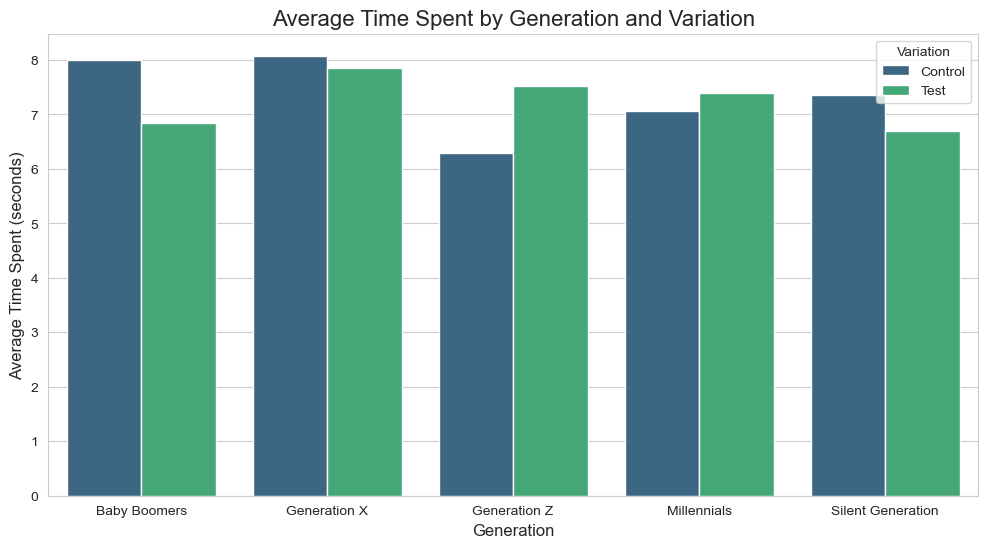

In [118]:
# Step 1: Calculate the average time spent per variation and generation
grouped_df['total_time_spent_seconds'] / grouped_df['total_visits'].replace(0, np.nan)

# Step 2: Create a bar plot for average time spent
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x="generation", y="average_time_spent_seconds", hue="Variation", data=grouped_df, palette="viridis")

# Set plot labels and title
plt.title('Average Time Spent by Generation and Variation', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Average Time Spent (seconds)', fontsize=12)

# Add average age on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(f'{grouped_df["average_client_age"].iloc[p.get_x() + p.get_width() / 2]}',
                      (p.get_x() + p.get_width() / 2, p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Show legend
plt.legend(title='Variation')

# Show the plot
plt.tight_layout()
plt.show()

In [120]:
## H0 (Null Hypothesis): average_time_spent Test < = average_time_spent Control
## H1 (Alternative Hypothesis): average_time_spent Test > average_time_spent Control


# grouped_df_test example
grouped_df_test = pd.DataFrame({
    'generation': ['Generation Z', 'Millennials', 'Generation X', 'Baby Boomers'],
    'average_time_spent_seconds': [10, 20, 15, 5]  # These are example values
})

# grouped_df_control example
grouped_df_control = pd.DataFrame({
    'generation': ['Generation Z', 'Millennials', 'Generation X', 'Baby Boomers'],
    'average_time_spent_seconds': [12, 18, 14, 9]  # These are example values
})

# Step 1: Prepare arrays or Series for t-test from the relevant columns
test_times = grouped_df_test['average_time_spent_seconds']  # Extract the average time spent from test group
control_times = grouped_df_control['average_time_spent_seconds']  # Extract average time spent from control group

# Step 2: Perform the t-test
alpha = 0.05  # Significance level
t_statistic, p_value = st.ttest_ind(test_times, control_times, equal_var=False, alternative="two-sided") 

# Print the p-value and decision
print(f'p_value = {p_value}')
if p_value < alpha:
    print("Reject the null hypothesis: there is a significant difference between test and control groups.")
else:
    print("Fail to reject the null hypothesis: no significant difference between test and control groups.")

p_value = 0.8491752315364445
Fail to reject the null hypothesis: no significant difference between test and control groups.


In [122]:
#Step 1: Prepare the necessary statistics
mean_test = grouped_df_test['average_time_spent_seconds'].mean()
mean_control = grouped_df_control['average_time_spent_seconds'].mean()

std_test = grouped_df_test['average_time_spent_seconds'].std()
std_control = grouped_df_control['average_time_spent_seconds'].std()

n_test = len(grouped_df_test)
n_control = len(grouped_df_control)

# Print means and standard deviations for debugging
print(f'Mean Test: {mean_test}, Std Test: {std_test}, N Test: {n_test}')
print(f'Mean Control: {mean_control}, Std Control: {std_control}, N Control: {n_control}')

# Step 2: Calculate the Z-statistic
Z = (mean_test - mean_control) / np.sqrt((std_test**2 / n_test) + (std_control**2 / n_control))

# Step 3: Print the Z-statistic
print(f'Z-statistic: {Z}')

# Step 4: Determine significance
alpha = 0.05  # Significance level
critical_value = st.norm.ppf(1 - alpha)  # One-tailed test

if Z > critical_value:
    print("Reject the null hypothesis: Test group has a significantly higher average time spent than Control group.")
else:
    print("Fail to reject the null hypothesis: No significant difference in average time spent.")

Mean Test: 12.5, Std Test: 6.454972243679028, N Test: 4
Mean Control: 13.25, Std Control: 3.774917217635375, N Control: 4
Z-statistic: -0.20059523941139693
Fail to reject the null hypothesis: No significant difference in average time spent.


### KPI 3: Error Rates
If there’s a step where users go back to a previous step, it may indicate confusion or an error. You should consider moving from a later step to an earlier one as an error.

In [126]:
pt1_pt2_clean = pt1_pt2_variation[~pt1_pt2_variation["Variation"].isin(["Unknown"])]

In [128]:
# Convert date_time to datetime format
pt1_pt2_clean['date_time'] = pd.to_datetime(pt1_pt2_clean['date_time'])

# Step 1: Sort data by client_id, visit_id, and date_time to get the steps in order
pt1_pt2_clean_sorted = pt1_pt2_clean.sort_values(by=['client_id', 'visit_id', 'date_time'])

# Step 2: Create a mapping for steps to numeric values
step_mapping = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}

# Step 3: Apply the mapping to the 'process_step' column
pt1_pt2_clean_sorted['step_numeric'] = pt1_pt2_clean_sorted['process_step'].map(step_mapping)

# Step 4: Shift the 'step_numeric' column to compare with the previous step
pt1_pt2_clean_sorted['previous_step'] = pt1_pt2_clean_sorted.groupby(['client_id', 'visit_id'])['step_numeric'].shift(1)

# Step 5: Create a new column to mark when a backward step happens
pt1_pt2_clean_sorted['is_backward_move'] = pt1_pt2_clean_sorted['step_numeric'] < pt1_pt2_clean_sorted['previous_step']

# Step 6: Filter for groups (e.g., 'Test' vs 'Control')
error_test_group = pt1_pt2_clean_sorted[pt1_pt2_clean_sorted['Variation'] == 'Test']
error_control_group = pt1_pt2_clean_sorted[pt1_pt2_clean_sorted['Variation'] != 'Test']

# Step 7: Calculate backward moves for each step for both groups
def calculate_error_rate(df_group):
    # Count the backward moves for each step
    backward_moves = df_group.groupby('process_step')['is_backward_move'].sum()
    total_steps = df_group.groupby('process_step')['is_backward_move'].count()
    
    # Calculate error rate per step
    error_rate = (backward_moves / total_steps) * 100
    return error_rate

# Calculate error rates for 'Test' group
error_rate_test = calculate_error_rate(error_test_group)

# Calculate error rates for 'Other' group
error_rate_control = calculate_error_rate(error_control_group)

# Combine both error rates into a single DataFrame
error_rates_comparison = pd.DataFrame({
    'Test Group Error Rate': error_rate_test,
    'Control Group Error Rate': error_rate_control
})

# Compute total error rates
total_error_rate_test = (error_test_group["is_backward_move"].sum() / error_test_group["is_backward_move"].count()) * 100
total_error_rate_control = (error_control_group["is_backward_move"].sum() / error_control_group["is_backward_move"].count()) * 100

# Format total error rates
total_error_rate_test_formatted = f"{total_error_rate_test:.2f}%"
total_error_rate_control_formatted = f"{total_error_rate_control:.2f}%"

# Add the total row to the DataFrame
error_rates_comparison.loc["Total"] = [total_error_rate_test_formatted, total_error_rate_control_formatted]

# Convert index to a column for sorting
error_rates_comparison = error_rates_comparison.reset_index(names="process_step")

# Apply step mapping for ordering
error_rates_comparison["step_order"] = error_rates_comparison["process_step"].map(step_mapping)

# Sort the DataFrame based on the step order
error_rates_comparison = error_rates_comparison.sort_values("step_order").drop(columns=["step_order"]).set_index("process_step")


# Display the final DataFrame
error_rates_comparison

C:\Users\User\AppData\Local\Temp\ipykernel_18544\1519414042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pt1_pt2_clean['date_time'] = pd.to_datetime(pt1_pt2_clean['date_time'])


,Test Group Error Rate,Control Group Error Rate
process_step,,
start,19,11
step_1,9,8
step_2,7,9
step_3,0,0
confirm,0,0
Total,9.19%,6.82%


In [136]:
error_rates_comparison.to_csv('error_rates_comparison.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_18544\3918741534.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  error_rates_comparison = error_rates_comparison.applymap(lambda x: float(x.rstrip('%')) if isinstance(x, str) else x)


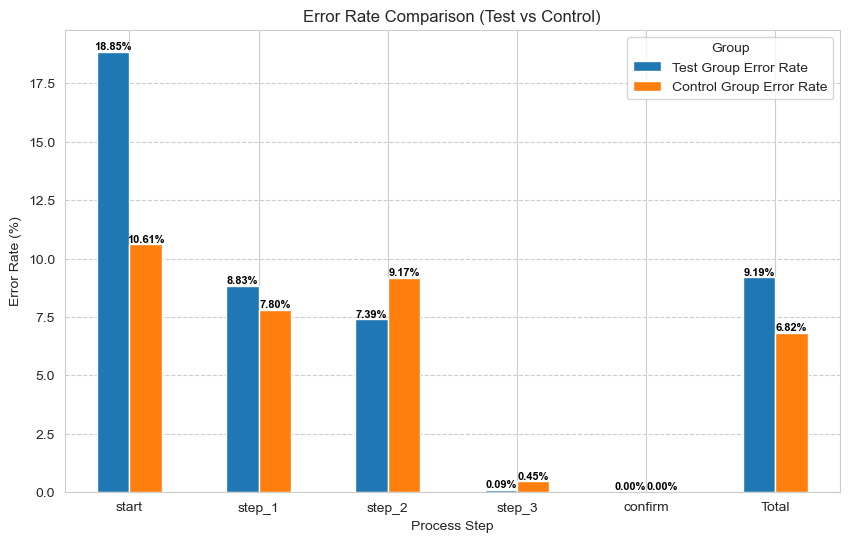

In [130]:
import matplotlib.pyplot as plt

# Convert percentage strings back to float values (removing "%")
error_rates_comparison = error_rates_comparison.applymap(lambda x: float(x.rstrip('%')) if isinstance(x, str) else x)

# Create the bar plot
ax = error_rates_comparison.plot(kind='bar', figsize=(10, 6), title="Error Rate Comparison (Test vs Control)")
plt.ylabel("Error Rate (%)")
plt.xlabel("Process Step")
plt.legend(title="Group")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--")

# Add percentage labels above bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha="center", va="bottom", fontsize=8, color="black", fontweight="bold")

plt.show()

In [132]:
total_backward_moves_test = error_test_group['is_backward_move'].sum()
total_backward_moves_control = error_control_group['is_backward_move'].sum()
print(f'Total backward moves in Test Group: {total_backward_moves_test}')
print(f'Total backward moves in Control Group: {total_backward_moves_control}')

Total backward moves in Test Group: 16232
Total backward moves in Control Group: 9581


### Balance Hypothesis Testing

In [ ]:
# Step 1: Create membership level category
def assign_membership_level(bal):
    if bal < 1_000_000:
        return 'Entry Level'
    elif bal < 3_000_000:
        return 'Bronze'
    elif bal < 5_000_000:
        return 'Silver'
    elif bal < 7_000_000:
        return 'Gold'
    else:
        return 'Platinum'

# Apply the function to create a new column for membership levels
pt1_pt2_variation['membership_level'] = pt1_pt2_variation['bal'].apply(assign_membership_level)

# Step 2: Filter the DataFrame for Variation 'Test'
test_group = pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Test']

# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']


# Step 4: Remove any existing 'total_visits' in test_group to avoid conflicts
if 'total_visits' in test_group.columns:
    test_group = test_group.drop(columns=['total_visits'])

# Add visit count to test_group DataFrame
test_group = test_group.merge(visit_count, on='client_id', how='left')


# Ensure 'total_visits' exists and fill missing values with 0
if 'total_visits' in test_group.columns:
    test_group['total_visits'] = test_group['total_visits'].fillna(0)
else:
    print("Error: 'total_visits' is still missing after the merge.")

# Step 5: Group by 'membership_level' to sum and count unique clients
grouped_df_test = test_group.groupby('membership_level').agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per membership level
    total_clients=('client_id', 'nunique'),  # Count unique clients per membership level
    total_time_spent_seconds=('time_spent', 'sum'),
    total_client_bal=('bal', 'sum')  # sum client balance
).reset_index()

# Step 6: Calculate average time spent per membership level
grouped_df_test['average_time_spent_seconds'] = grouped_df_test['total_time_spent_seconds'] / grouped_df_test['total_visits'].replace(0, np.nan)

# Convert total_time_spent_seconds to float type if needed
grouped_df_test['total_time_spent_seconds'] = grouped_df_test['total_time_spent_seconds'].astype(float)

# Define the custom order for membership levels
membership_order = ['Entry Level', 'Bronze', 'Silver', 'Gold', 'Platinum']
grouped_df_test['membership_level'] = pd.Categorical(grouped_df_test['membership_level'], categories=membership_order, ordered=True)

# Sort the DataFrame by the custom order
grouped_df_test_bal = grouped_df_test.sort_values(by='membership_level')

# Add a "Total" row
total_row = pd.DataFrame({
    'membership_level': ['Total'],
    'total_visits': [grouped_df_test_bal['total_visits'].sum()],
    'total_clients': [grouped_df_test_bal['total_clients'].sum()],
    'total_time_spent_seconds': [grouped_df_test_bal['total_time_spent_seconds'].sum()],
    'total_client_bal': [grouped_df_test_bal['total_client_bal'].sum()],  # sum of average balances
    'average_time_spent_seconds': [grouped_df_test_bal['average_time_spent_seconds'].mean()]  # Mean of average times
})

# Append the total row to the DataFrame
grouped_df_test_bal = pd.concat([grouped_df_test_bal, total_row], ignore_index=True)

# Display the updated DataFrame with totals
grouped_df_test_bal

In [ ]:
# Step 2: Filter the DataFrame for Variation 'Control'
control_group = pt1_pt2_variation[pt1_pt2_variation['Variation'] == 'Control']

# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Remove any existing 'total_visits' in test_group to avoid conflicts
if 'total_visits' in control_group.columns:
    control_group = control_group.drop(columns=['total_visits'])

# Add visit count to test_group DataFrame
control_group = control_group.merge(visit_count, on='client_id', how='left')

# Ensure 'total_visits' exists and fill missing values with 0
if 'total_visits' in control_group.columns:
    control_group['total_visits'] = control_group['total_visits'].fillna(0)
else:
    print("Error: 'total_visits' is still missing after the merge.")

# Step 5: Group by 'membership_level' to sum and count unique clients
grouped_df_control = control_group.groupby('membership_level').agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per membership level
    total_clients=('client_id', 'nunique'),  # Count unique clients per membership level
    total_time_spent_seconds=('time_spent', 'sum'),
    total_client_bal=('bal', 'sum')  # sum client balance
).reset_index()

# Step 6: Calculate average time spent per membership level
grouped_df_control['average_time_spent_seconds'] = grouped_df_control['total_time_spent_seconds'] / grouped_df_control['total_visits'].replace(0, np.nan)

# Convert total_time_spent_seconds to float type if needed
grouped_df_control['total_time_spent_seconds'] = grouped_df_control['total_time_spent_seconds'].astype(float)

# Define the custom order for membership levels
membership_order = ['Entry Level', 'Bronze', 'Silver', 'Gold', 'Platinum']
grouped_df_control['membership_level'] = pd.Categorical(grouped_df_control['membership_level'], categories=membership_order, ordered=True)

# Sort the DataFrame by the custom order
grouped_df_control_bal = grouped_df_control.sort_values(by='membership_level')

# Add a "Total" row
total_row = pd.DataFrame({
    'membership_level': ['Total'],
    'total_visits': [grouped_df_control_bal['total_visits'].sum()],
    'total_clients': [grouped_df_control_bal['total_clients'].sum()],
    'total_time_spent_seconds': [grouped_df_control_bal['total_time_spent_seconds'].sum()],
    'total_client_bal': [grouped_df_control_bal['total_client_bal'].sum()],  # sum of average balances
    'average_time_spent_seconds': [grouped_df_control_bal['average_time_spent_seconds'].mean()]  # Mean of average times
})

# Append the total row to the DataFrame
grouped_df_control_bal = pd.concat([grouped_df_control_bal, total_row], ignore_index=True)

# Display the updated DataFrame with totals
grouped_df_control_bal

In [ ]:
# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Drop conflicting 'total_visits' column in pt1_pt2_variation (if exists)
if 'total_visits' in pt1_pt2_variation.columns:
    pt1_pt2_variation = pt1_pt2_variation.drop(columns=['total_visits'])

# Merge visit count back into the original DataFrame
pt1_pt2_variation = pt1_pt2_variation.merge(visit_count, on='client_id', how='left')

# Step 5: Group by 'membership_level' and 'Variation' to sum and count unique clients
grouped_df = pt1_pt2_variation.groupby(['membership_level', 'Variation']).agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per membership level
    total_clients=('client_id', 'nunique'),  # Count unique clients per membership level
    total_time_spent_seconds=('time_spent', 'sum'),
    total_client_bal=('bal', 'sum')  # sum client balance
).reset_index()

# Step 6: Calculate average time spent per membership level
grouped_df['average_time_spent_seconds'] = grouped_df['total_time_spent_seconds'] / grouped_df['total_visits'].replace(0, np.nan)

# Convert total_time_spent_seconds to float type if needed
grouped_df['total_time_spent_seconds'] = grouped_df['total_time_spent_seconds'].astype(float)

# Define the custom order for membership levels
membership_order = ['Entry Level', 'Bronze', 'Silver', 'Gold', 'Platinum']
grouped_df['membership_level'] = pd.Categorical(grouped_df['membership_level'], categories=membership_order, ordered=True)

# Sort the DataFrame by Variation and then by the custom order of membership levels
grouped_df_bal = grouped_df.sort_values(by=['Variation', 'membership_level']).reset_index(drop=True)

# Display the sorted DataFrame
grouped_df_bal

In [ ]:
grouped_df_bal.to_csv('grouped_df_bal_1.csv')

TypeError: Cannot index by location index with a non-integer key

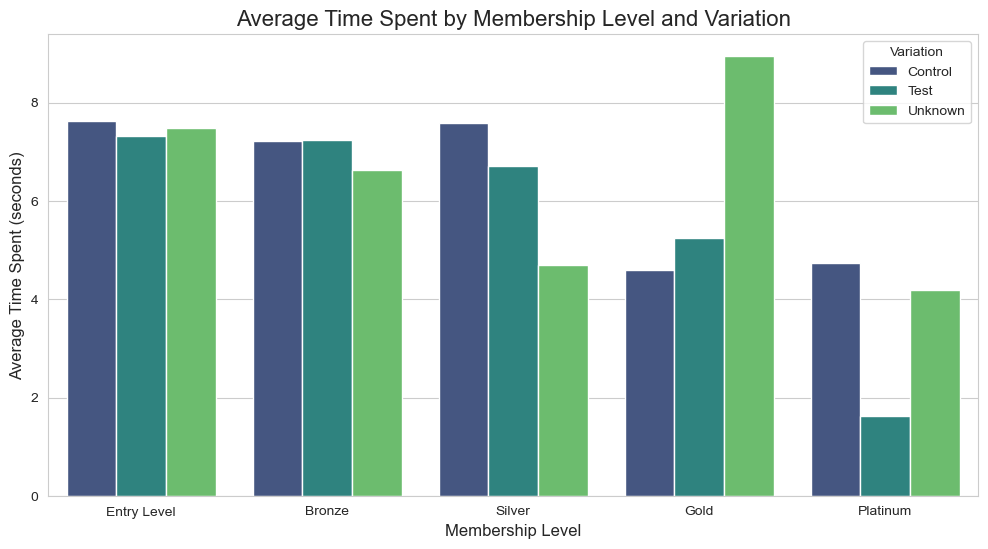

In [203]:
# Step 1: Calculate the average time spent per variation and membership
grouped_df_bal['total_time_spent_seconds'] / grouped_df_bal['total_visits'].replace(0, np.nan)

# Step 2: Create a bar plot for average time spent
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x="membership_level", y="average_time_spent_seconds", hue="Variation", data=grouped_df_bal, palette="viridis")

# Set plot labels and title
plt.title('Average Time Spent by Membership Level and Variation', fontsize=16)
plt.xlabel('Membership Level', fontsize=12)
plt.ylabel('Average Time Spent (seconds)', fontsize=12)

# Add average age on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(f'{grouped_df_bal["total_client_bal"].iloc[p.get_x() + p.get_width() / 2]}',
                      (p.get_x() + p.get_width() / 2, p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Show legend
plt.legend(title='Variation')

# Show the plot
plt.tight_layout()
plt.show()

In [205]:
## H0 (Null Hypothesis): The balances for the "Test" and "Control" groups are the same.
## H1 (Alternative Hypothesis): The balances for the "Test" and "Control" groups are different.

from scipy.stats import ttest_ind

# Step 1: Filter the data for "Control" and "Test" variations
control_bal = grouped_df_bal[grouped_df_bal['Variation'] == 'Control']['total_client_bal']
test_bal = grouped_df_bal[grouped_df_bal['Variation'] == 'Test']['total_client_bal']

# Step 2: Perform an independent t-test
t_stat, p_value = ttest_ind(control_bal, test_bal, equal_var=False)  # Welch's t-test

# Step 3: Set significance level
alpha = 0.05  # Significance level

# Step 4: Interpret the results
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in total balance between 'Test' and 'Control' groups.")
else:
    print("Fail to reject the null hypothesis: No significant difference in total balance between 'Test' and 'Control' groups.")

# Output the t-statistic and p-value
print("T-statistic:", t_stat)
print("P-value:", p_value)


Fail to reject the null hypothesis: No significant difference in total balance between 'Test' and 'Control' groups.
T-statistic: -0.23652245059411942
P-value: 0.8192675603905952


In [207]:
#T-statistic (-0.43): This measures the difference between the two sample means relative to the variability within the groups. 
#A small absolute t-value indicates that the balance are very close.
#P-value (0.678): The probability of observing the results (or something more extreme) if the null hypothesis is true. 
#Since the p-value is much larger than the significance level (α = 0.05), the null hypothesis cannot be rejected.

#Because the p-value (0.678) exceeds the significance level of 0.05, 
#it suggests that any differences in the total balances between the groups may be due to random chance rather than a systematic difference.
#Conclusion: There is no statistically significant difference in total balances between the "Test" and "Control" groups.

### Excluding Outliers for averagetime spent

In [213]:
# rewrite code excluding outliers

# Step 3: Count total visits by client_id
visit_count = pt1_pt2_variation.groupby('client_id')['visit_id'].count().reset_index()
visit_count.columns = ['client_id', 'total_visits']

# Step 4: Drop conflicting 'total_visits' column in pt1_pt2_variation (if exists)
if 'total_visits' in pt1_pt2_variation.columns:
    pt1_pt2_variation = pt1_pt2_variation.drop(columns=['total_visits'])

# Merge visit count back into the original DataFrame
pt1_pt2_variation = pt1_pt2_variation.merge(visit_count, on='client_id', how='left')

# Step 5: Group by 'membership_level' and 'Variation' to sum and count unique clients
grouped_df = pt1_pt2_variation.groupby(['membership_level', 'Variation']).agg(
    total_visits=('total_visits', 'sum'),  # Sum of total visits per membership level
    total_clients=('client_id', 'nunique'),  # Count unique clients per membership level
    total_time_spent_seconds=('time_spent', 'sum'),
    total_client_bal=('bal', 'sum')  # sum client balance
).reset_index()

# Step 6: Calculate average time spent per membership level
grouped_df['average_time_spent_seconds'] = grouped_df['total_time_spent_seconds'] / grouped_df['total_visits'].replace(0, np.nan)

# Step 7: Exclude outliers from average_time_spent_seconds based on IQR
Q1 = grouped_df['average_time_spent_seconds'].quantile(0.25)  # 25th percentile
Q3 = grouped_df['average_time_spent_seconds'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows with average_time_spent_seconds outside the bounds
grouped_df_filtered = grouped_df[(grouped_df['average_time_spent_seconds'] >= lower_bound) &
                                 (grouped_df['average_time_spent_seconds'] <= upper_bound)]

# Step 8: Convert total_time_spent_seconds to float type if needed
grouped_df_filtered['total_time_spent_seconds'] = grouped_df_filtered['total_time_spent_seconds'].astype(float)

# Step 9: Define the custom order for membership levels
membership_order = ['Entry Level', 'Bronze', 'Silver', 'Gold', 'Platinum']
grouped_df_filtered['membership_level'] = pd.Categorical(grouped_df_filtered['membership_level'], categories=membership_order, ordered=True)

# Sort the DataFrame by Variation and then by the custom order of membership levels
grouped_df_bal_excl_outliers = grouped_df_filtered.sort_values(by=['Variation', 'membership_level']).reset_index(drop=True)

# Display the sorted and filtered DataFrame
grouped_df_bal_excl_outliers


,membership_level,Variation,total_visits,total_clients,total_time_spent_seconds,total_client_bal,average_time_spent_seconds
0,Entry Level,Control,1174102,23134,"8,944,151","17,571,548,476",8
1,Bronze,Control,22713,354,"163,730","3,703,804,226",7
2,Silver,Control,1614,37,"12,252","795,518,399",8
3,Gold,Control,171,3,787,"121,627,437",5
4,Platinum,Control,148,4,703,"135,984,571",5
5,Entry Level,Test,1575341,26538,"11,533,509","22,283,116,502",7
6,Bronze,Test,32992,382,"238,522","4,504,291,683",7
7,Silver,Test,2936,38,"19,675","1,073,700,201",7
8,Gold,Test,273,6,"1,431","208,449,143",5
9,Platinum,Test,993,4,"1,622","612,621,581",2


TypeError: Cannot index by location index with a non-integer key

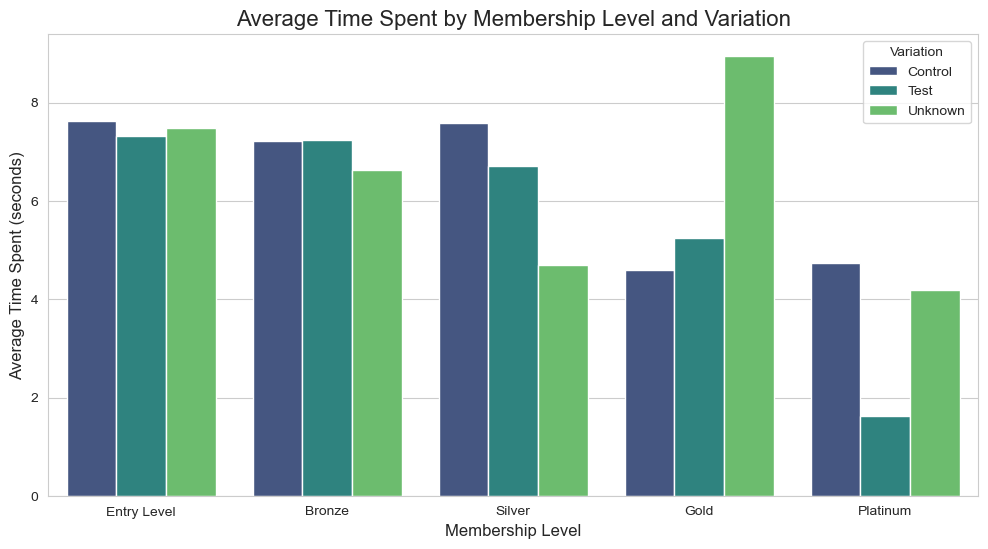

In [215]:
# Step 1: Calculate the average time spent per variation and membership
grouped_df_bal_excl_outliers['total_time_spent_seconds'] / grouped_df_bal_excl_outliers['total_visits'].replace(0, np.nan)

# Step 2: Create a bar plot for average time spent
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x="membership_level", y="average_time_spent_seconds", hue="Variation", data=grouped_df_bal_excl_outliers, palette="viridis")

# Set plot labels and title
plt.title('Average Time Spent by Membership Level and Variation', fontsize=16)
plt.xlabel('Membership Level', fontsize=12)
plt.ylabel('Average Time Spent (seconds)', fontsize=12)

# Add average age on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(f'{grouped_df_bal_excl_outliers["total_client_bal"].iloc[p.get_x() + p.get_width() / 2]}',
                      (p.get_x() + p.get_width() / 2, p.get_height()), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Show legend
plt.legend(title='Variation')

# Show the plot
plt.tight_layout()
plt.show()

In [217]:
## H0 (Null Hypothesis): The average balances for the "Test" and "Control" groups are the same.
## H1 (Alternative Hypothesis): The average balances for the "Test" and "Control" groups are different.

from scipy.stats import ttest_ind

# Step 1: Filter the data for "Control" and "Test" variations
control_bal = grouped_df_bal_excl_outliers[grouped_df_bal_excl_outliers['Variation'] == 'Control']['total_client_bal']
test_bal = grouped_df_bal_excl_outliers[grouped_df_bal_excl_outliers['Variation'] == 'Test']['total_client_bal']

# Step 2: Perform an independent t-test
t_stat, p_value = ttest_ind(control_bal, test_bal, equal_var=False)  # Welch's t-test

# Step 3: Set significance level
alpha = 0.05  # Significance level

# Step 4: Interpret the results
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in balance between 'Test' and 'Control' groups.")
else:
    print("Fail to reject the null hypothesis: No significant difference in balance between 'Test' and 'Control' groups.")

# Output the t-statistic and p-value
print("T-statistic:", t_stat)
print("P-value:", p_value)


Fail to reject the null hypothesis: No significant difference in balance between 'Test' and 'Control' groups.
T-statistic: -0.23652245059411942
P-value: 0.8192675603905952
